In [ ]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr
import arviz as az
import jax.scipy.special as jss
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
#jax.config.update("jax_enable_x64", True)


num_dimensions = 200
num_data = 200
noise_magnitude_on_each_point = 0.1
num_fourier_entries = 300
total_length = 20
dx = total_length/num_dimensions
fixed_points_linspace = jnp.arange(num_dimensions)*dx + dx/2
full_fourier_period_linspace = jnp.arange(num_fourier_entries)*dx + dx/2
boundary_padding = total_length*(num_fourier_entries/num_dimensions - 1)
omegas = 2 * jnp.pi * jnp.fft.fftfreq(num_fourier_entries, d = dx)
num_fitting_params = 3
normalization_factor = num_fourier_entries/jnp.sqrt(total_length + boundary_padding)

hardcoded_logvar = 0
hardcoded_lognu = jnp.log(0.5)
hardcoded_logscale = 0

num_overall_steps = 100
burn_in = 10

num_integration_steps = 50
step_size = 0.023

normalization_factor = num_fourier_entries/jnp.sqrt(total_length + boundary_padding)

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, logscale, lognu = inference_params
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))

def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))

def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]

def fft_field(noise, inference_params):
    return fft_field_hartley(noise, inference_params)

<ErrorbarContainer object of 3 artists>

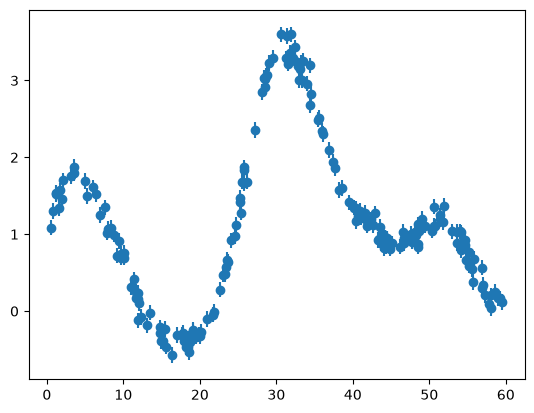

In [ ]:

diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2

cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2, k3, k4 = jr.split(jr.key(100), 4)
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=total_length)
xi = jr.normal(k3, shape = num_fourier_entries)
true_field = fft_field(xi, (hardcoded_logvar, hardcoded_logscale, hardcoded_lognu))
y_obs_true = jnp.interp(x_obs, fixed_points_linspace, true_field)
#y_obs_true = jnp.sin(30*x_obs/10) * jnp.exp(-5*x_obs/10)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)
noise = y_obs_err * jr.normal(k2, shape=y_obs_true.shape)
y_obs = y_obs_true + noise

plt.errorbar(x_obs, y_obs, yerr = noise_magnitude_on_each_point, fmt='o', label='Observations')


In [4]:
def logvarprior(logvar):
    return -0.5*logvar**2
def logscaleprior(logscale):
    return -0.5*logscale**2
def lognuprior(lognu):
    return -0.5*lognu**2
def response(model_values):
    return jnp.interp(x_obs, fixed_points_linspace, model_values)

R = jax.jacobian(response)(fixed_points_linspace)

def negative_logdensity(x):
    logvar = x[0]
    logscale = x[1]
    lognu = x[2]
    xi = x[3:]
    inference_params = (logvar, logscale, lognu)
    negative_log_p_s = -logvarprior(logvar) - logscaleprior(logscale) -lognuprior(lognu) + 0.5*xi.T @ xi
    res = y_obs - R @ fft_field(xi, inference_params)
    negative_log_p_d_given_s = 0.5*res.T @ inv_cov_data_matrix @ res
    return negative_log_p_s + negative_log_p_d_given_s

Text(0.5, 1.0, 'New Diagonal Covariance vs Old Diagonal Covariance')

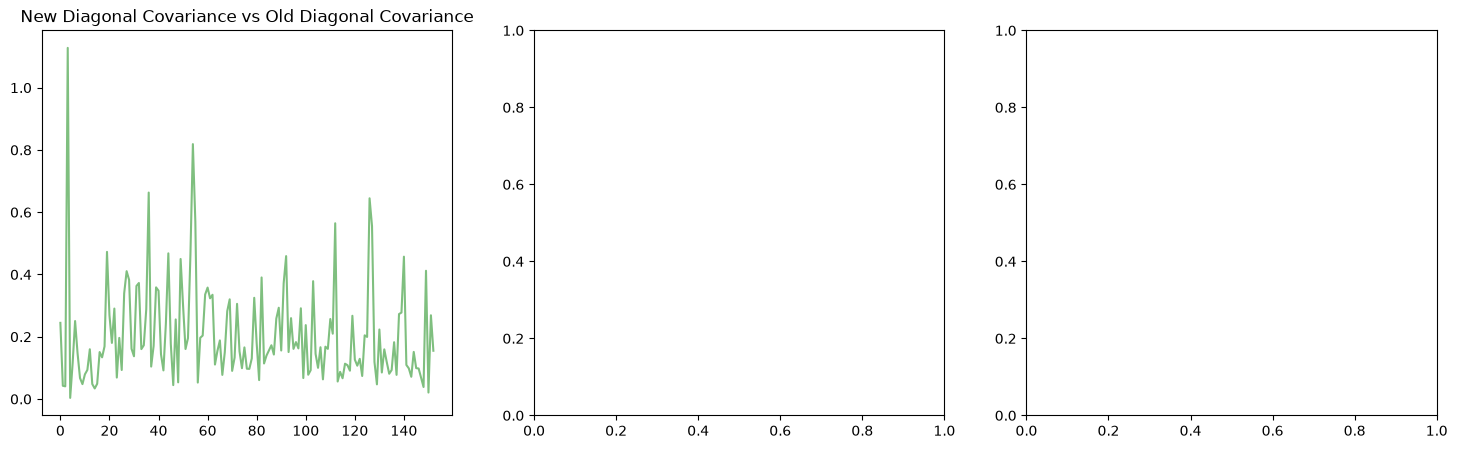

In [ ]:
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)
sampler = HMCSampler(
    negative_logdensity= negative_logdensity,
    num_integration_steps= num_integration_steps,
    step_size= step_size,
    #inv_mass_matrix = jnp.array(np.load('cov_matrix_fitting_three_parameters_matern.npy')),
    inv_mass_matrix = jnp.eye(num_fourier_entries + num_fitting_params),
    #inv_mass_matrix = jnp.array(jnp.load('cov_matrix_july_15.npy'))
    alpha=1.0
)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(2)
initial_coordinates = jnp.zeros(num_fourier_entries + num_fitting_params)


overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)

logvars = overall_data_arr[:, 0]
logscales = overall_data_arr[:, 1]
lognus = overall_data_arr[:, 2]
overall_position_arr = overall_data_arr[:, 3:]  

inference_params = (logvars, logscales, lognus)

overall_position_arr = jax.vmap(fft_field, in_axes=(0, 0))(
    overall_position_arr, inference_params
)
overall_position_arr = overall_position_arr[:, 0:num_dimensions]

mean_position = overall_position_arr.sum(axis=0)/num_good_samples

vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)
old_cov = jnp.array(np.load('cov_matrix_fitting_three_parameters_matern.npy'))
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
timegrid = jnp.arange(num_fourier_entries + num_fitting_params)
axes[0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
#axes[0].plot(timegrid, jnp.diagonal(old_cov), color = "Red", alpha = 0.5)
axes[0].set_title("New Diagonal Covariance vs Old Diagonal Covariance")
#np.save('cov_matrix_july_15.npy', np.asarray(cov))
#np.save('cov_matrix_fitting_three_parameters_matern.npy', np.asarray(cov))

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   1.,   0.,   1.,   1.,   0.,   2.,   0.,
          0.,   2.,   1.,   1.,   0.,   1.,   2.,   1.,   0.,   2.,   1.,
          5.,   1.,   3.,   0.,   2.,   1.,   1.,   6.,   6.,   2.,   2.,
          1.,   2.,   1.,  10.,   6., 123.]),
 array([0.98911905, 0.98933667, 0.98955429, 0.9897719 , 0.98998952,
        0.99020714, 0.99042475, 0.99064237, 0.99085999, 0.9910776 ,
        0.99129522, 0.99151284, 0.99173045, 0.99194813, 0.99216574,
        0.99238336, 0.99260098, 0.99281859, 0.99303621, 0.99325383,
        0.99347144, 0.99368906, 0.99390668, 0.99412429, 0.99434191,
        0.99455953, 0.99477714, 0.99499476, 0.99521238, 0.99542999,
        0.99564761, 0.99586523, 0.99608284, 0.99630046, 0.99651808,
        0.99673569, 0.99695331, 0.99717093, 0.9973886 , 0.99760622,
        0.99782383, 0.99804145, 0.99825907, 0.99847668, 0.9986943 ,
        0.99891192, 0.99912953, 0.99934715, 0.

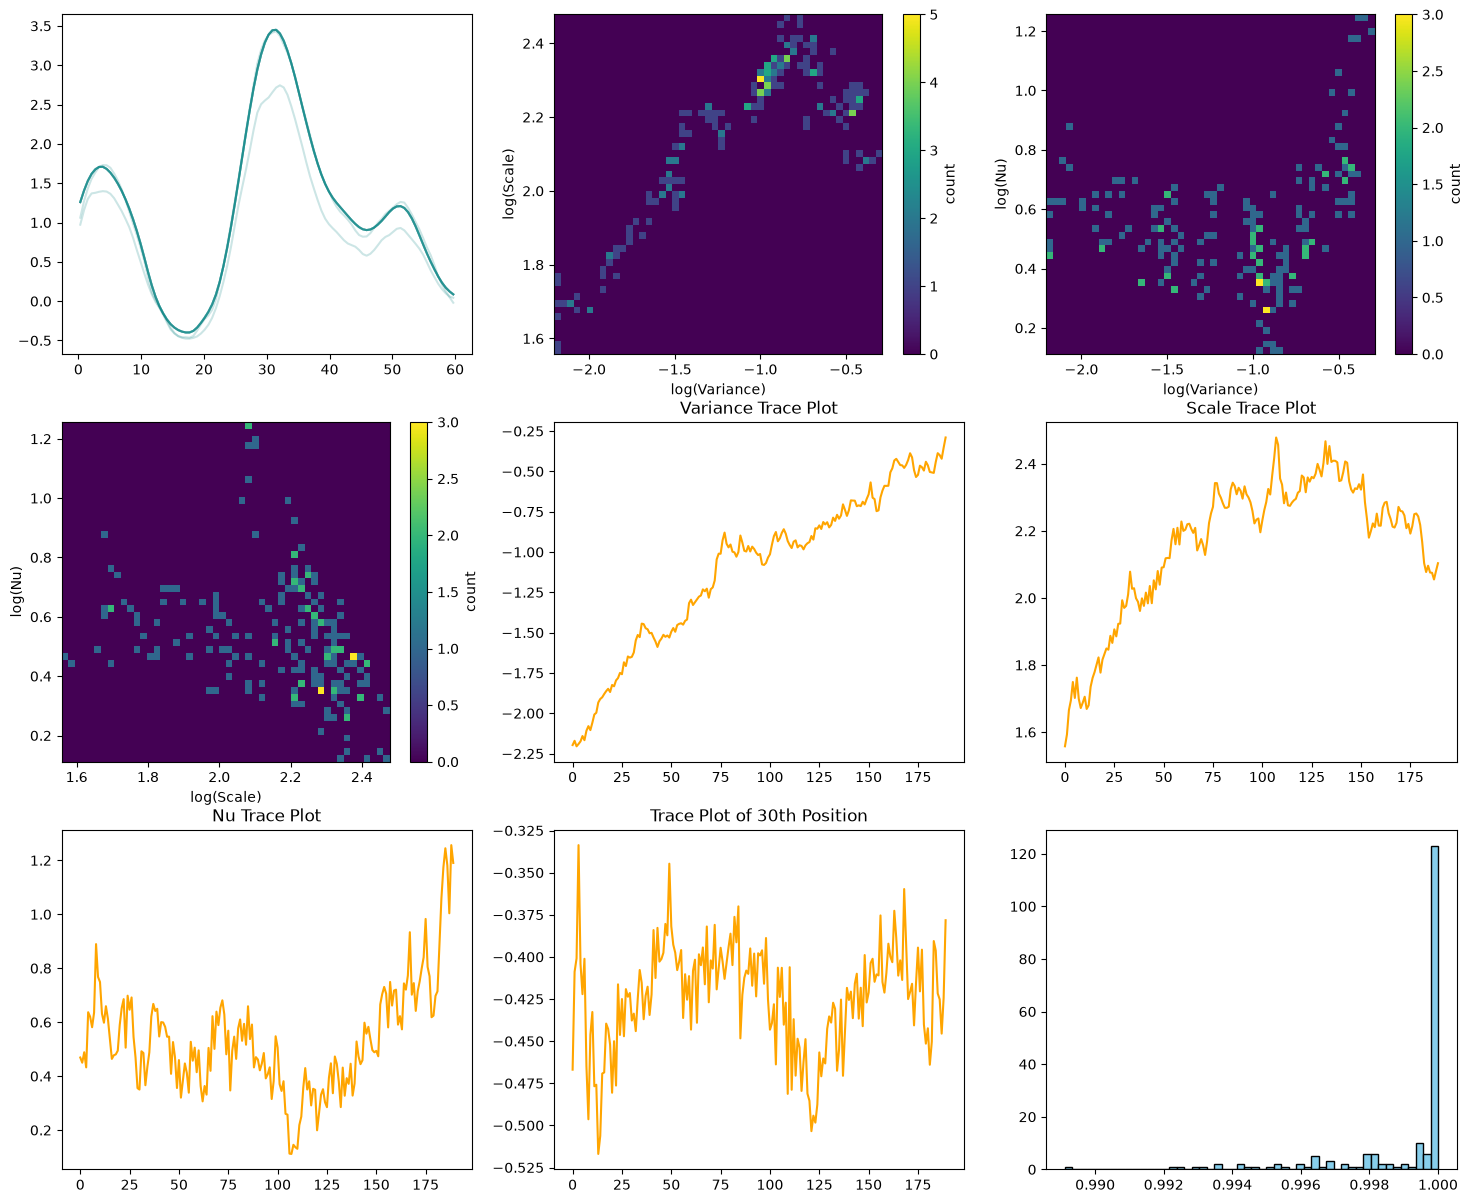

In [6]:
fig, axes = plt.subplots(3, 3, figsize = (18, 15))
for i in range (0, 10):
    axes[0][0].plot(fixed_points_linspace, overall_position_arr[100*i, :], color = "teal", alpha = 0.2)
    #axes[0][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
#axes[0][0].plot(fixed_points_linspace, mean_position, color = "orange", alpha = 1)


bins1 = 50  # or (nx, ny) tuple for different bin counts per axis
H, xedges, yedges = jnp.histogram2d(logvars, logscales, bins=bins1)


# H has shape (nx, ny); transpose so x is horizontal, y is vertical for imshow
im = axes[0][1].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][1], label='count')

bins2 = 50  # or (nx, ny) tuple for different bin counts per axis
H, xedges, yedges = jnp.histogram2d(logvars, lognus, bins=bins2)

# H has shape (nx, ny); transpose so x is horizontal, y is vertical for imshow
im = axes[0][2].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][2], label='count')

bins3 = 50  # or (nx, ny) tuple for different bin counts per axis
H, xedges, yedges = jnp.histogram2d(logscales, lognus, bins=bins3)

# H has shape (nx, ny); transpose so x is horizontal, y is vertical for imshow
im = axes[1][0].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[1][0], label='count')

axes[0][1].set_xlabel("log(Variance)")
axes[0][1].set_ylabel("log(Scale)")

axes[0][2].set_xlabel("log(Variance)")
axes[0][2].set_ylabel("log(Nu)")

axes[1][0].set_xlabel("log(Scale)")
axes[1][0].set_ylabel("log(Nu)")

axes[1][1].plot(time_arr, logvars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")

axes[1][2].plot(time_arr, logscales, color = "Orange")
axes[1][2].set_title("Scale Trace Plot")

axes[2][0].plot(time_arr, lognus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")

axes[2][1].plot(time_arr, overall_position_arr[:, 30], color = "Orange")
axes[2][1].set_title("Trace Plot of 30th Position")

axes[2][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')
